# Plot Fig S11A
- 3wnn umap of TEA-seq data

In [11]:
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from matplotlib import pyplot as plt

In [12]:
import hisepy as hp

In [31]:
# define working path
data_path = "/home/workspace/data/preRA_teaseq/EXP-00243/totalVI/"
fig_path = "/home/workspace/data/ALTRA_manusript/figures/"
output_path = "/home/workspace/data/preRA_teaseq/EXP-00243/totalVI/output_results/"
# os.mkdir(fig_path)
# os.mkdir(output_path)
# define a project name
proj_name = "PreRA_TEASeq_"
sc.settings.figdir = fig_path
sc.settings.autosave = False
sc.set_figure_params(vector_friendly=True, dpi_save=300)

In [15]:
import matplotlib
from matplotlib import pyplot as plt

plt.rcParams["figure.dpi"] = 100

In [14]:
# set fig size
plt.rcParams["figure.figsize"] = [10, 8]

In [8]:
npg_color = [
    "#E64B35FF",
    "#4DBBD5FF",
    "#00A087FF",
    "#3C5488FF",
    "#F39B7FFF",
    "#8491B4FF",
    "#91D1C2FF",
    "#DC0000FF",
    "#7E6148FF",
    "#B09C85FF",
]
cluster_colors = [
    "#DC050C",
    "#FB8072",
    "#1965B0",
    "#7BAFDE",
    "#882E72",
    "#B17BA6",
    "#FF7F00",
    "#FDB462",
    "#E7298A",
    "#E78AC3",
    "#33A02C",
    "#B2DF8A",
    "#55A1B1",
    "#8DD3C7",
    "#A6761D",
    "#E6AB02",
    "#7570B3",
    "#BEAED4",
    "#666666",
    "#999999",
    "#aa8282",
    "#d4b7b7",
    "#8600bf",
    "#ba5ce3",
    "#808000",
    "#aeae5c",
    "#1e90ff",
    "#00bfff",
    "#56ff0d",
    "#ffff00",
]
ari_colors = ["#5AAA46", "#F59F00"]
cluster_colors_32 = [
    "#DC050C",
    "#F9786B",
    "#3668A8",
    "#68A0D5",
    "#844F8D",
    "#A36295",
    "#E07D40",
    "#FD9C35",
    "#F27075",
    "#E751A1",
    "#A7918D",
    "#57B247",
    "#9CD192",
    "#5EA9B4",
    "#8FCAB6",
    "#A8771C",
    "#E3A902",
    "#7F75A1",
    "#B2A3CE",
    "#79767E",
    "#8A8A8A",
    "#A38A8A",
    "#C2A0A0",
    "#AB58BB",
    "#9D29CF",
    "#A3698B",
    "#8E8E1D",
    "#88A686",
    "#1899FF",
    "#0BC7DF",
    "#60FF0C",
    "#FFFF00",
]

# Processing individual modalities


In [13]:
# download the data
hp.cache_files(['74b00c24-acd2-4a8b-8e9d-2480c296c208'])

['/home/workspace/input/569004694/cohorts/74b00c24-acd2-4a8b-8e9d-2480c296c208/PreRA_teaseq_qc_filtered_cells_5modality_rmBR2024.h5mu']

In [16]:
# load the three modalities data
prera_tea = mu.read(
    '/home/workspace/input/569004694/cohorts/74b00c24-acd2-4a8b-8e9d-2480c296c208/PreRA_teaseq_qc_filtered_cells_5modality_rmBR2024.h5mu', 
    backed = 'r'
)

/home/workspace/environment/scanpy/lib/python3.12/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/scanpy/lib/python3.12/site-packages/mudata/_core/mudata.py:931: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/home/workspace/environment/scanpy/lib/python3.12/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var m

In [17]:
prera_tea

MuData object with n_obs × n_vars = 88967 × 700415 backed at '/home/workspace/input/569004694/cohorts/74b00c24-acd2-4a8b-8e9d-2480c296c208/PreRA_teaseq_qc_filtered_cells_5modality_rmBR2024.h5mu'
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'cluster ratio', 'subject_id', 'Ethnicity', 'Race', 'Birth Year', 'Sex', 'cohort', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'ADT_snn_res.0.5', 'atac_cell_id', 'n_mito', 'n_fragments', 'peaks_frac', 'altius_frac', 'DoubletScore', 'DoubletEnrichment', 'Clusters', 'iterative_lsi_number_umap_dimension_1', 'iterative_lsi_number_umap_dimension_2', 'nCount_Tiles', 'nFeature_Tiles', 'nCount_cleanadt', 'nFeature_cleanadt', 'cleanadt_snn_res.0.5', 'Tiles_snn_res.0.8', 'SCT.weight', 'ADT.weight', 'Tiles.weight', 'wsnn_res.0.5', 'wsnn_res.0.8', 'l1_cell_types', 'l2_cell_types', 'clean_l2_cell_types', 'nCount_rna', 'nFeature_rna', 'immunehealth_l1', 'immunehealth_l1_conf_score', 'immunehealth_l2', 'immunehealth_l2_conf_score', 'immunehealth_l3', 'immunehealth_l3_conf_score', 'leiden_wnn_0_5', 'manual_labels'
  uns:	'clean_l2_cell_types_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'l2_cell_types_colors', 'leiden', 'manual_labels_colors', 'umap', 'wnn'
  obsm:	'X_umap'
  obsp:	'wnn_connectivities', 'wnn_distances'
  5 modalities
    rna:	88967 x 36601
      obs:	'log10umi', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_labels', 'conf_score', 'majority_voting', 'over_clustering'
      var:	'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Archr_naive_wilcoxon', 'clean_l2_cell_types_colors', 'cohort_colors', 'dendrogram_leiden', 'hvg', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'leiden', 'leiden_colors', 'leiden_wilcoxon', 'leiden_wilcoxon_C10vsC0', 'log1p', 'neighbors', 'pca', 'rna:leiden_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    prot:	88967 x 166
      var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'clean_l2_cell_types_colors', 'hvg', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'l2_cell_types_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'dsb'
      obsp:	'connectivities', 'distances'
    atac:	88967 x 637859
      obs:	'altius_count', 'altius_frac', 'barcodes', 'batch_id', 'BlacklistRatio', 'cell_name', 'chip_id', 'DoubletEnrichment', 'DoubletScore', 'gene_bodies_count', 'gene_bodies_frac', 'Gex_MitoRatio', 'Gex_nGenes', 'Gex_nUMI', 'Gex_RiboRatio', 'n_duplicate', 'n_fragments', 'n_mito', 'n_unique', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags', 'NucleosomeRatio', 'original_barcodes', 'PassQC', 'pbmc_sample_id', 'peaks_count', 'peaks_frac', 'pool_id', 'PromoterRatio', 'ReadsInBlacklist', 'ReadsInPromoter', 'ReadsInTSS', 'singlet', 'tss_count', 'tss_frac', 'TSSEnrichment', 'well_id', 'Clusters', 'subject_id', 'cohort', 'Birth.Year', 'Sex', 'wsnn_res.0.5', 'l1_cell_types', 'l2_cell_types', 'clean_l2_cell_types', 'ReadsInPeaks', 'FRIP', 'MochaPeak_clusters_1', 'n_genes_by_counts', 'total_counts', 'leiden'
      var:	'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
      uns:	'X_name', 'leiden', 'neighbors', 'umap'


### plot S7A


In [22]:
matplotlib.rcParams["pdf.fonttype"] = 42

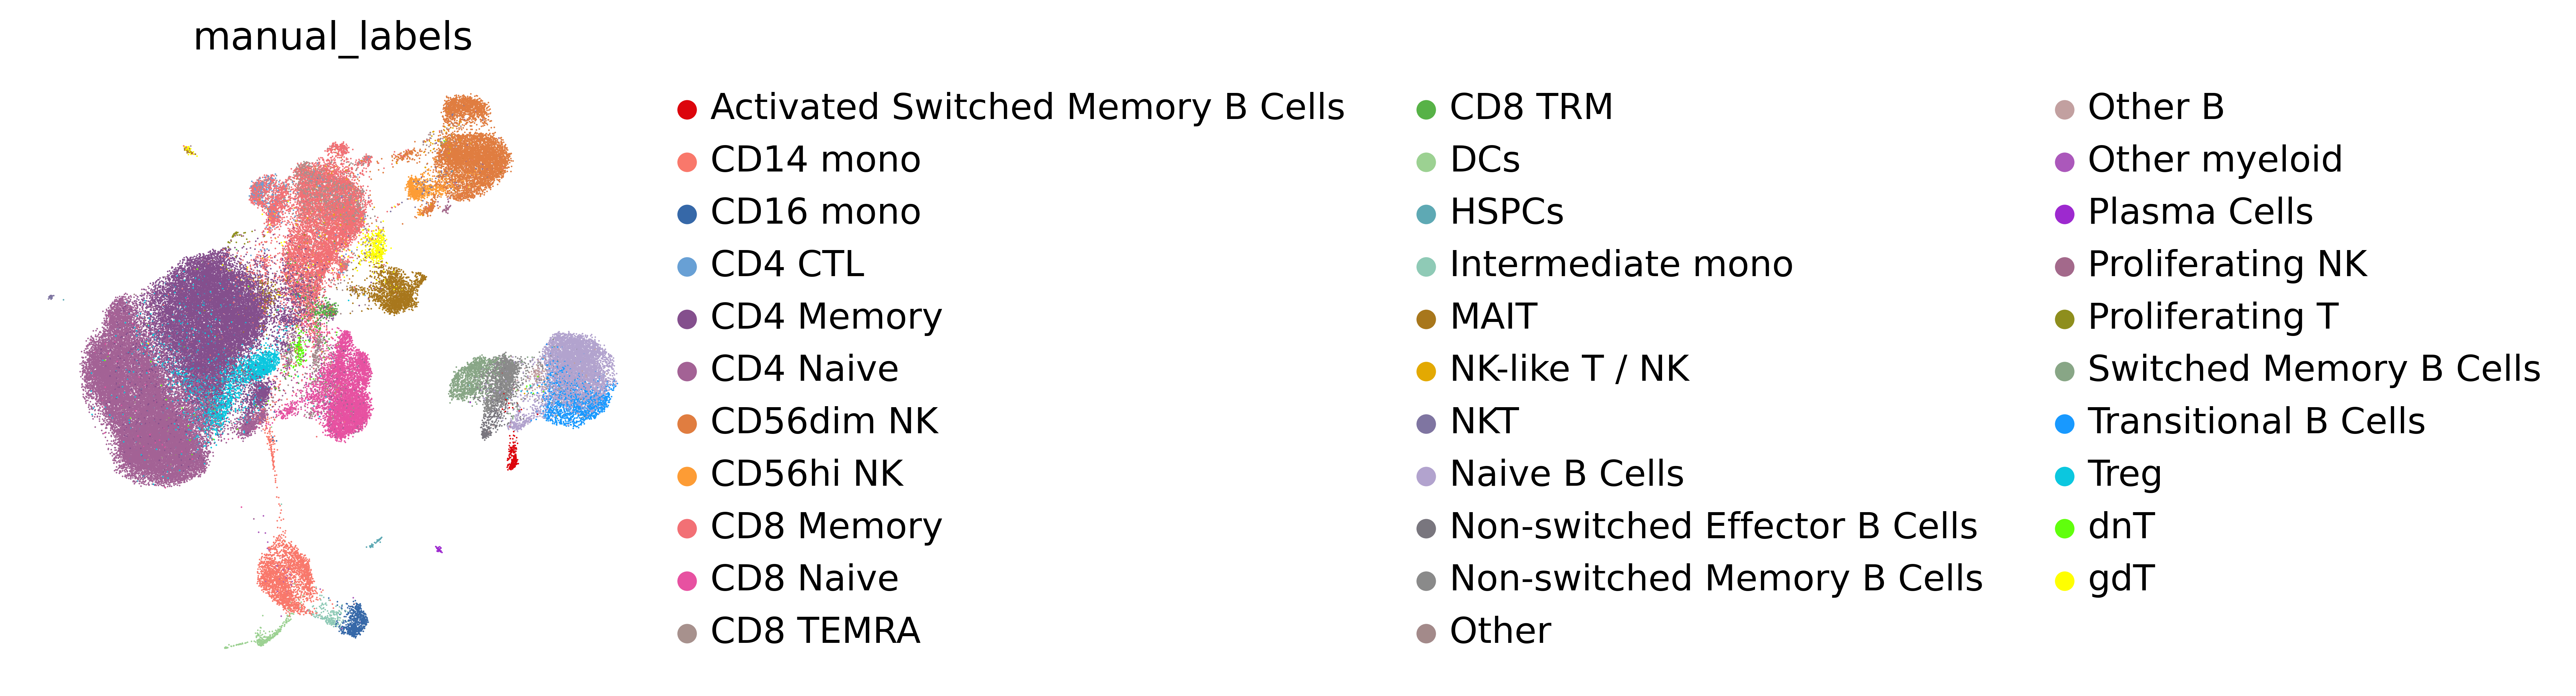

In [36]:
with plt.rc_context({"figure.figsize": (4, 4), "figure.dpi": (300)}):
    mu.pl.umap(
        prera_tea,
        color=["manual_labels"],
        palette=cluster_colors_32,  
        save=proj_name + "_manual_labels_legend.pdf",
        show=True,
        frameon=False
    )


In [39]:
import matplotlib.patheffects as pe
from adjustText import adjust_text


def gen_mpl_labels(
    adata,
    groupby,
    exclude=(),
    ax=None,
    adjust_kwargs=None,
    text_kwargs=None,
    color_by_group=False,
):
    if adjust_kwargs is None:
        adjust_kwargs = {"text_from_points": False}
    if text_kwargs is None:
        text_kwargs = {}

    medians = {}

    for g, g_idx in adata.obs.groupby(groupby).groups.items():
        if g in exclude:
            continue
        medians[g] = np.median(adata[g_idx].obsm["X_umap"], axis=0)

    # Fill the text colors dictionary
    text_colors = {group: None for group in adata.obs[groupby].cat.categories}

    if color_by_group and groupby + "_colors" in adata.uns:
        for i, group in enumerate(adata.obs[groupby].cat.categories):
            if group in exclude:
                continue
            text_colors[group] = adata.uns[groupby + "_colors"][i]

    if ax is None:
        texts = [
            plt.text(x=x, y=y, s=k, color=text_colors[k], **text_kwargs)
            for k, (x, y) in medians.items()
        ]
    else:
        texts = [
            ax.text(x=x, y=y, s=k, color=text_colors[k], **text_kwargs)
            for k, (x, y) in medians.items()
        ]

    adjust_text(texts, **adjust_kwargs)

/tmp/ipykernel_6002/3359429263.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for g, g_idx in adata.obs.groupby(groupby).groups.items():


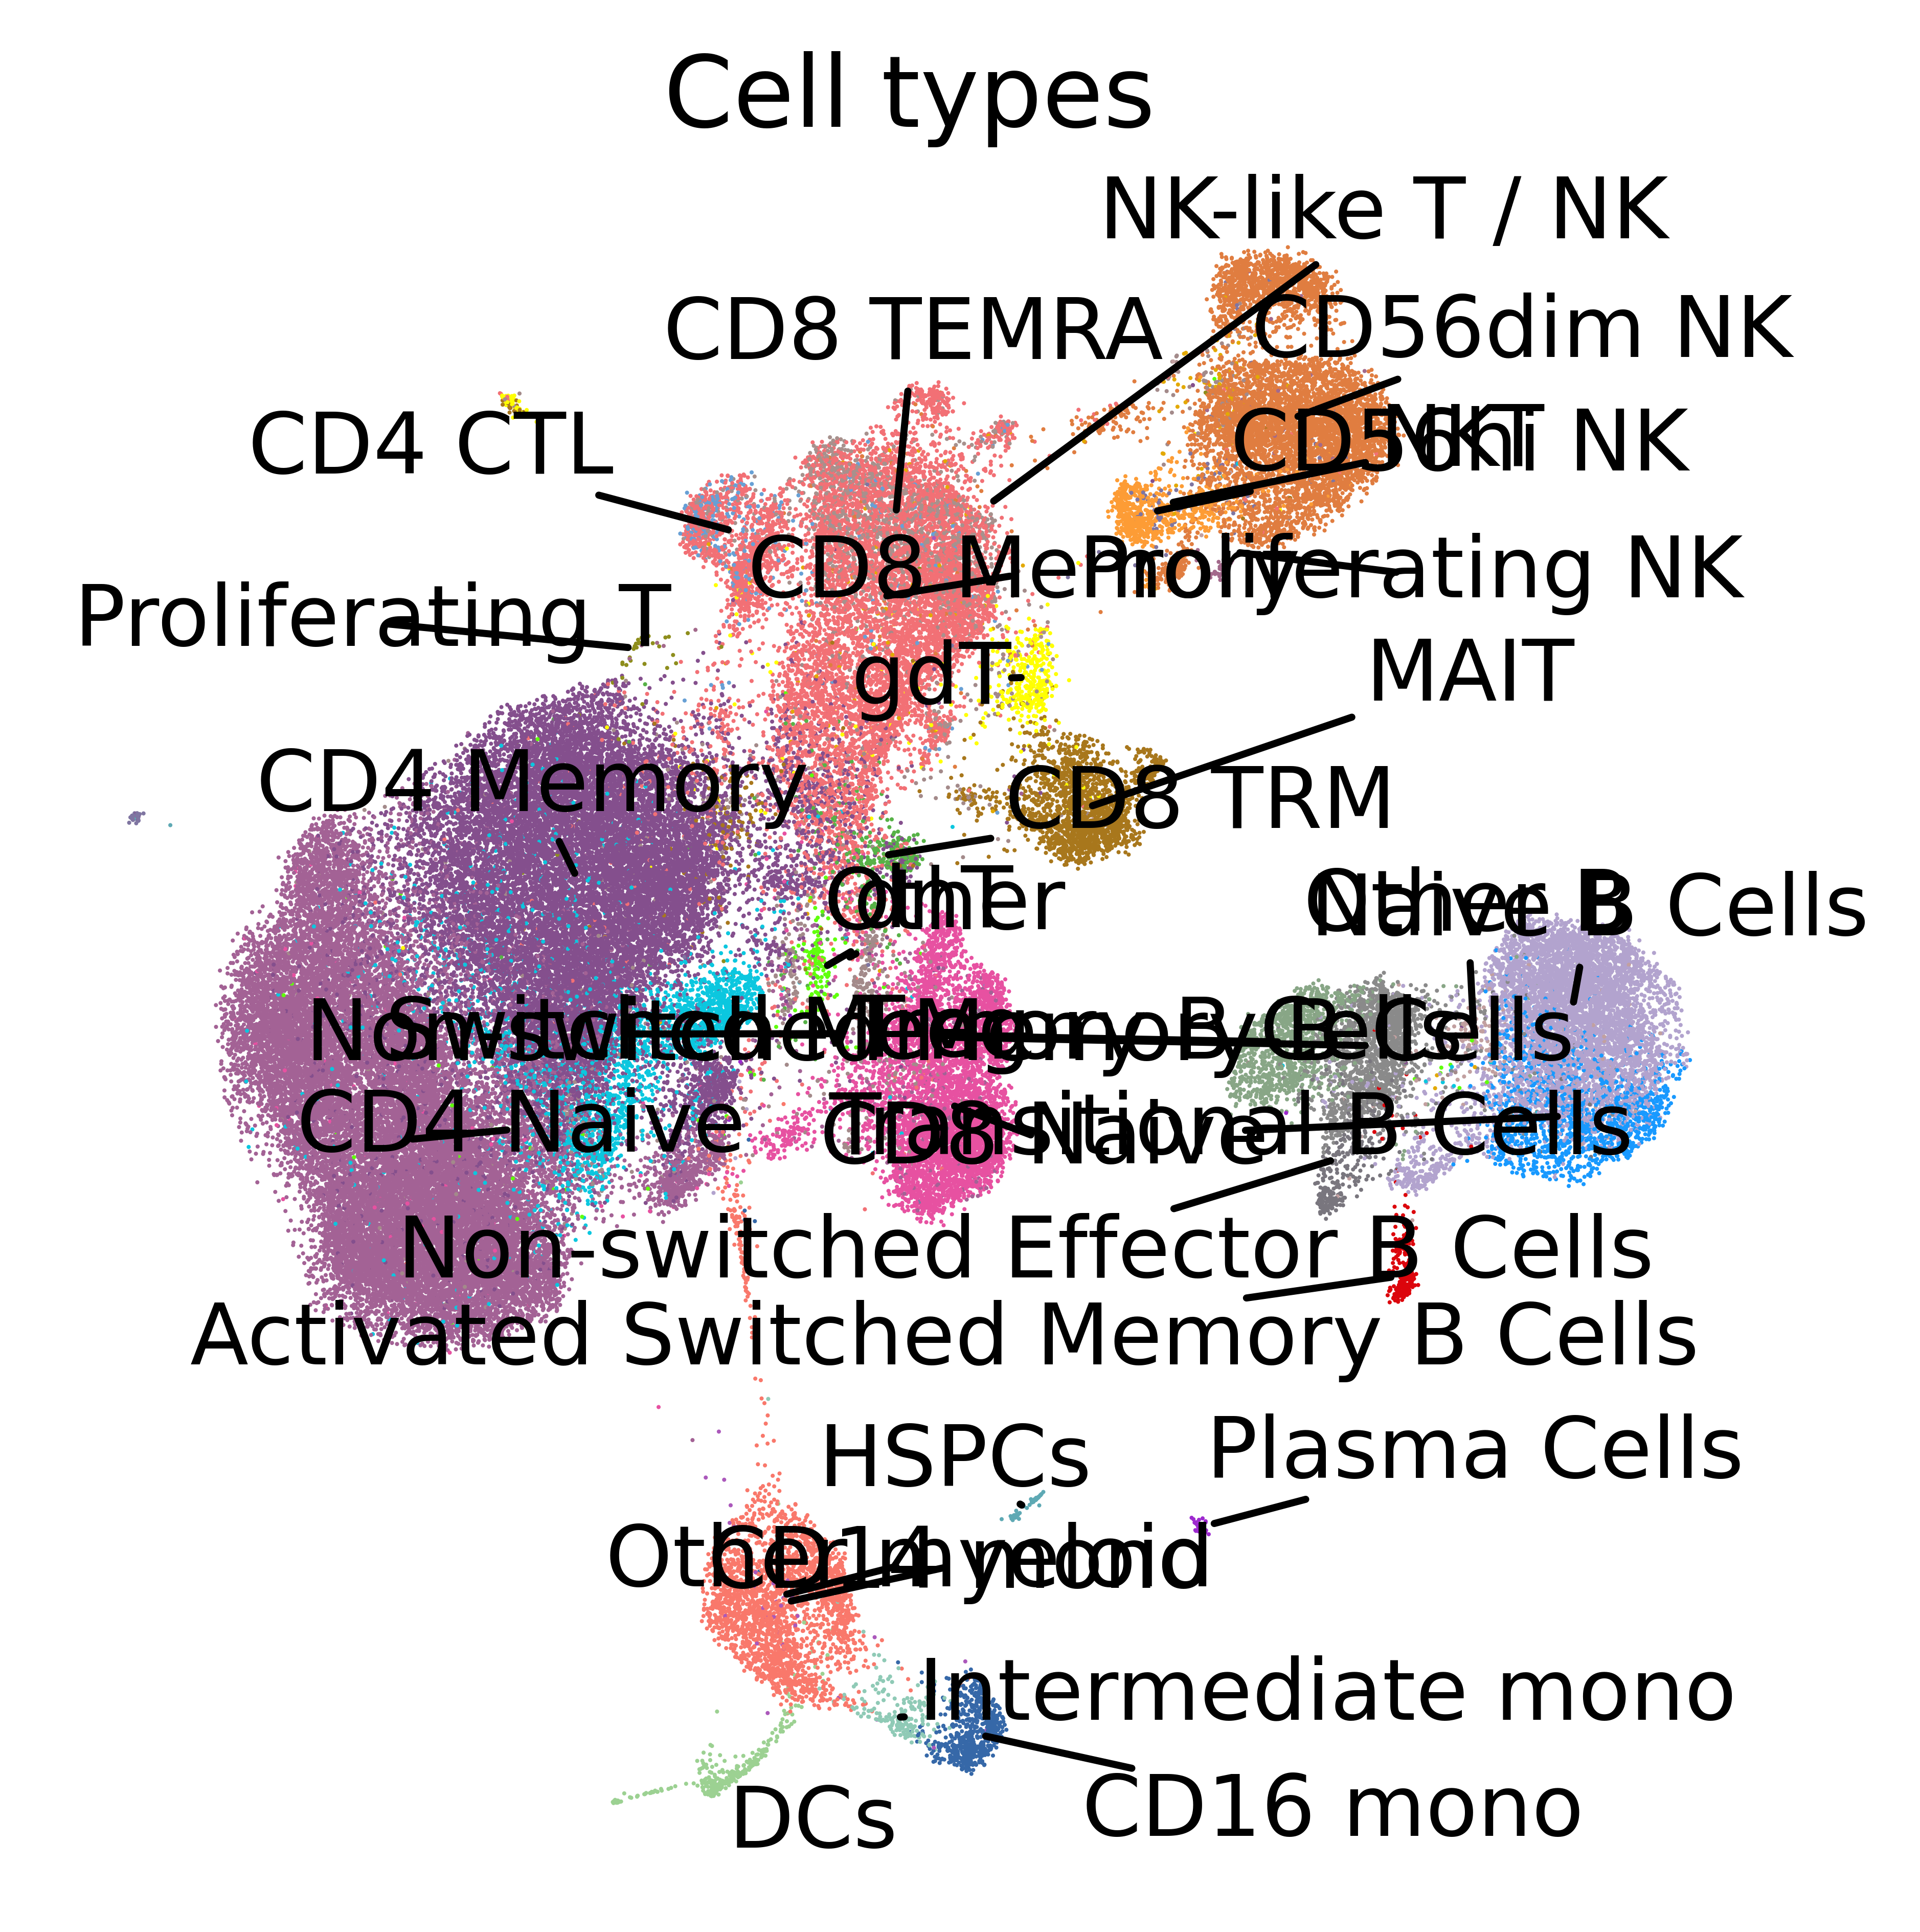

In [37]:
cell_type_key = "manual_labels"
with plt.rc_context(
    {"figure.figsize": (4, 4), "figure.dpi": 500, "figure.frameon": True}
):
    ax = mu.pl.umap(
        prera_tea,
        color=cell_type_key,
        show=False,
        palette=cluster_colors_32,
        legend_loc=None,
        frameon=False,
    )
    gen_mpl_labels(
        prera_tea,
        cell_type_key,
        exclude=("None",),  # This was before we had the `nan` behaviour
        ax=ax,
        adjust_kwargs=dict(arrowprops=dict(arrowstyle="-", color="black")),
        text_kwargs=dict(
            fontsize=12  # , path_effects=[pe.withStroke(linewidth=1, foreground="darkgray")]
        ),
        color_by_group=False,
    )
    ax.set_xlabel("WNN UMAP1")
    ax.set_ylabel("WNN UMAP2")
    ax.set_title("Cell types")
    fig = ax.get_figure()
    fig.tight_layout()
    plt.show()
    fig.savefig(fig_path + proj_name + "_3wnn_umap_manual_labels_repel.pdf")

In [38]:
import session_info
session_info.show()

/home/workspace/environment/scanpy/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
